# CIFAR‑10 Exploratory Data Analysis (EDA)

This notebook performs **exploratory data analysis** on the CIFAR‑10 dataset.

CIFAR‑10 contains **60,000 RGB images** belonging to **10 classes**.

Image size: **32×32×3**  
Dataset split:

- Training set: 50,000 images
- Test set: 10,000 images

Goal of this notebook:

1. Load and inspect the dataset
2. Understand image structure
3. Visualize sample images
4. Explore class distribution
5. Analyze pixel values
6. Prepare data for modeling

⚠️ This notebook focuses **only on EDA**. Model training is handled separately in the `.py` script.

## Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2026-03-15 19:15:23.192445: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 19:15:23.214705: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-15 19:15:23.214724: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-15 19:15:23.215299: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-15 19:15:23.219211: I tensorflow/core/platform/cpu_feature_guar

## Load CIFAR‑10 Dataset

In [2]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

170498071/170498071 [==============================] - 20s 0us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


## Dataset Structure

Each image has shape:

```
32 x 32 x 3
```

Where:
- 32 → height
- 32 → width
- 3 → RGB color channels

In [3]:
x_train[0].shape

(32, 32, 3)

## Define Class Labels

In [4]:
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

## Visualize Sample Images

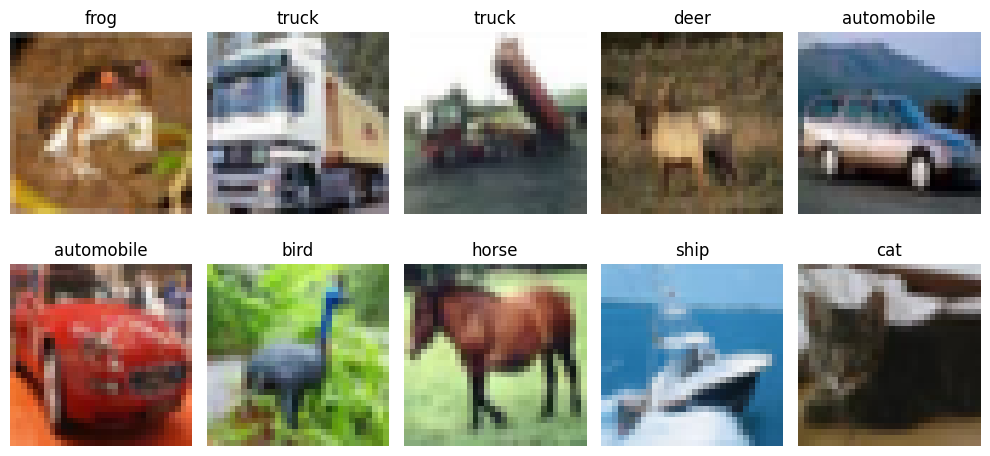

In [5]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()

## Class Distribution

Text(0, 0.5, 'Count')

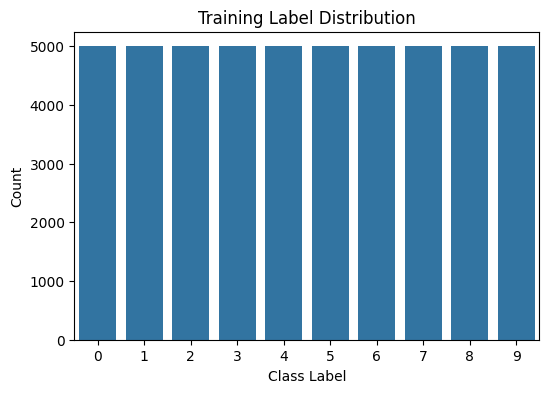

In [6]:
labels = pd.Series(y_train.flatten())

plt.figure(figsize=(6,4))
sns.countplot(x=labels)
plt.title("Training Label Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")

## Pixel Value Range

Pixel values range from **0 to 255** for RGB images.

In [7]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


## Pixel Value Distribution

Text(0, 0.5, 'Frequency')

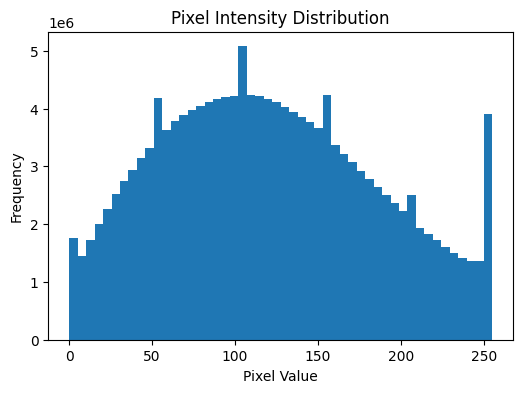

In [8]:
plt.figure(figsize=(6,4))
plt.hist(x_train.flatten(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

## Normalize Pixel Values

In [9]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

print("Max normalized value:", np.max(x_train_norm))

Max normalized value: 1.0


## Visualize Normalized Image

(-0.5, 31.5, 31.5, -0.5)

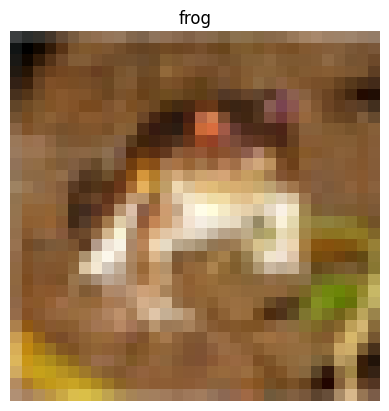

In [10]:
plt.imshow(x_train_norm[0])
plt.title(class_names[y_train[0][0]])
plt.axis("off")

## Mean Image

We compute the **average image** across the dataset.
This helps visualize the overall structure of CIFAR‑10 images.

(-0.5, 31.5, 31.5, -0.5)

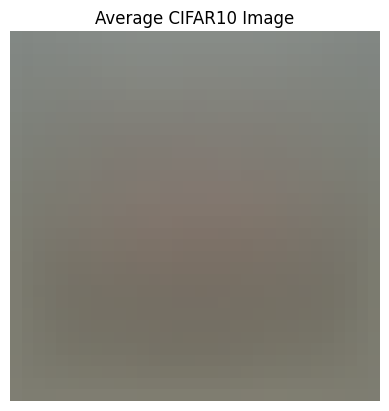

In [11]:
mean_image = np.mean(x_train_norm, axis=0)

plt.imshow(mean_image)
plt.title("Average CIFAR10 Image")
plt.axis("off")

# Conclusion

From this exploratory analysis we learned:

- Images are **32×32 RGB**
- Pixel values range **0–255**
- Dataset is fairly balanced across classes
- Normalization converts pixels to **0–1 range**

Next step: Train a **CNN model** using this dataset (handled in the training script).

# Complete cnn basic notebook

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 30, 30, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 15, 15, 

2026-03-15 19:15:50.461197: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-15 19:15:50.483936: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-15 19:15:50.487565: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Epoch 1/20


2026-03-15 19:15:51.788492: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-03-15 19:15:51.913189: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8900
2026-03-15 19:15:52.724093: I external/local_xla/xla/service/service.cc:168] XLA service 0x78e5d3833a60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-15 19:15:52.724105: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-03-15 19:15:52.727613: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773602152.793138  203003 device_compiler.h:186] Compiled cluster using XL

625/625 [==============================] - 7s 6ms/step - loss: 1.6596 - accuracy: 0.3954 - val_loss: 1.4247 - val_accuracy: 0.4699
Epoch 2/20
625/625 [==============================] - 3s 5ms/step - loss: 1.2530 - accuracy: 0.5534 - val_loss: 1.1891 - val_accuracy: 0.5769
Epoch 3/20
625/625 [==============================] - 3s 5ms/step - loss: 1.0553 - accuracy: 0.6318 - val_loss: 1.0292 - val_accuracy: 0.6362
Epoch 4/20
625/625 [==============================] - 3s 5ms/step - loss: 0.9316 - accuracy: 0.6758 - val_loss: 1.2344 - val_accuracy: 0.6089
Epoch 5/20
625/625 [==============================] - 3s 5ms/step - loss: 0.8550 - accuracy: 0.7043 - val_loss: 0.9215 - val_accuracy: 0.6829
Epoch 6/20
625/625 [==============================] - 3s 5ms/step - loss: 0.7843 - accuracy: 0.7269 - val_loss: 0.7217 - val_accuracy: 0.7511
Epoch 7/20
625/625 [==============================] - 3s 5ms/step - loss: 0.7389 - accuracy: 0.7470 - val_loss: 0.6661 - val_accuracy: 0.7698
Epoch 8/20
625/62

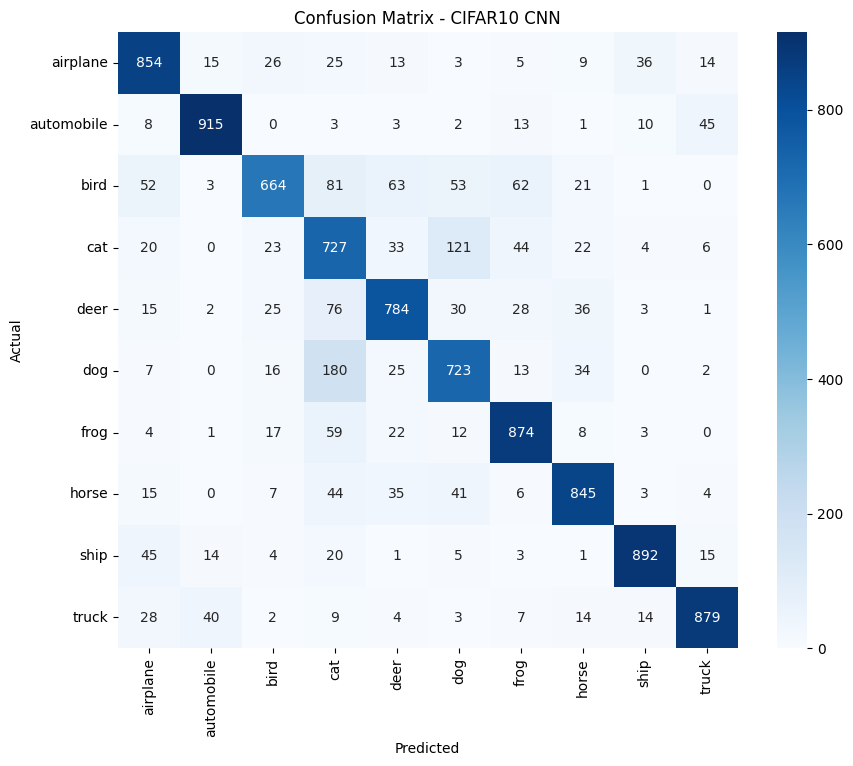

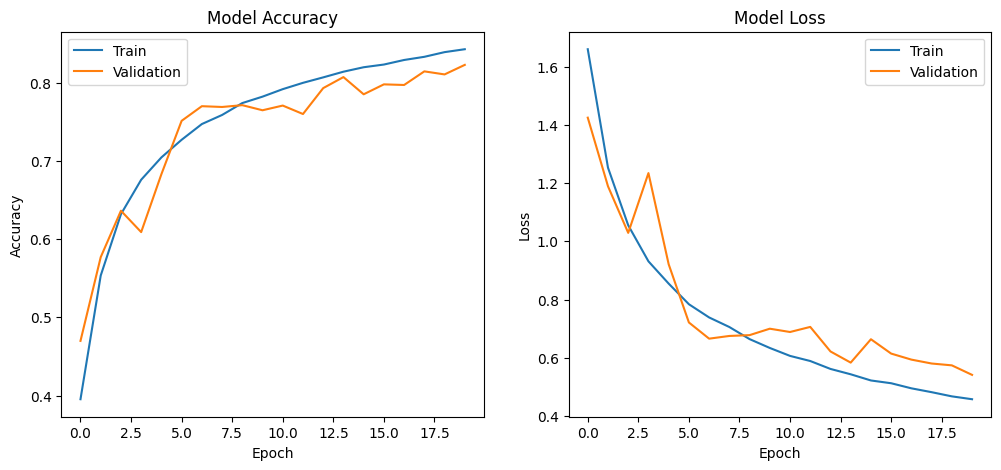

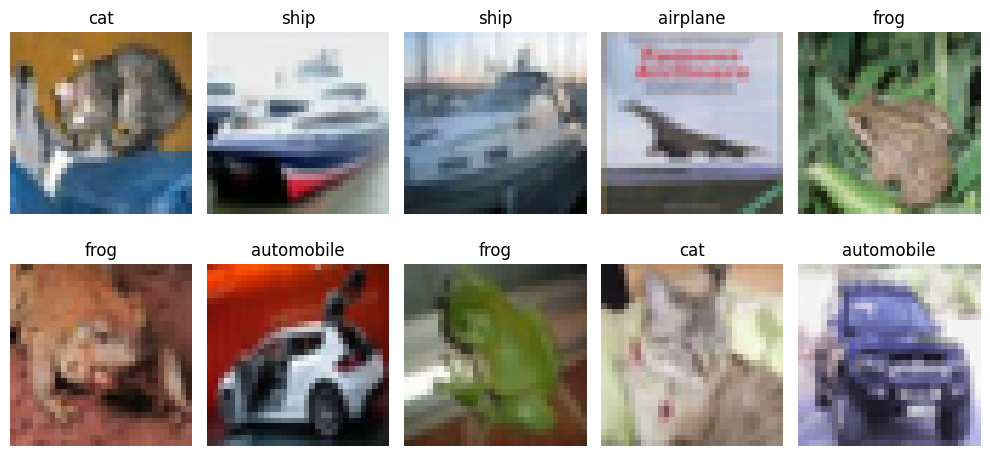

: 

In [ ]:
# ==========================
# 1. Import Libraries
# ==========================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix

# ==========================
# 2. Load Dataset
# ==========================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()

# ==========================
# 3. Normalize Images
# ==========================
x_train = x_train / 255.0
x_test = x_test / 255.0

# ==========================
# 4. Class Names
# ==========================
class_names = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]

# ==========================
# 5. Build CNN Model
# ==========================
model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Third Convolution Block
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

# Fully Connected Layer
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

# ==========================
# 6. Compile Model
# ==========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================
# 7. Model Summary
# ==========================
model.summary()

# ==========================
# 8. Train Model
# ==========================
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

# ==========================
# 9. Evaluate Model
# ==========================
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_accuracy)

# ==========================
# 10. Predictions
# ==========================
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# ==========================
# 11. Classification Report
# ==========================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# ==========================
# 12. Confusion Matrix
# ==========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CIFAR10 CNN")
plt.show()

# ==========================
# 13. Training Curves
# ==========================
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

# ==========================
# 14. Show Sample Predictions
# ==========================
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title(class_names[y_pred[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()